In questo lavoro analizziamo il fenomeno del churn in un’azienda di telecomunicazioni. Il dataset raccoglie informazioni su 7043 clienti e comprende variabili relative a dati demografici, tipologie di servizio sottoscritto, modalità di pagamento e storico contrattuale. L’obiettivo principale è comprendere i fattori che portano un cliente a lasciare il servizio.

In [61]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.preprocessing import StandardScaler, LabelEncoder

Carichiamo il file principale


In [62]:
file1_path = 'Telecommunications_Industry/CustomerChurn.xlsx'
df1 = pd.read_excel(file1_path)

df1.head()

,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,318537,7590-VHVEG,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,152148,5575-GNVDE,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,326527,3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,845894,7795-CFOCW,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,503388,9237-HQITU,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Carichiamo il secondo file

In [63]:
file2_path = 'Telecommunications_Industry/Telco_customer_churn_demographics.xlsx'
df_dem = pd.read_excel(file2_path)

df_dem.head()

,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
0,8779-QRDMV,1,Male,78,No,Yes,No,No,0
1,7495-OOKFY,1,Female,74,No,Yes,Yes,Yes,1
2,1658-BYGOY,1,Male,71,No,Yes,No,Yes,3
3,4598-XLKNJ,1,Female,78,No,Yes,Yes,Yes,1
4,4846-WHAFZ,1,Female,80,No,Yes,Yes,Yes,1


Adesso uniamo i due dataset usando la colonna in comune Customer ID, stando attenti a selezionare solo le colonne proprie dei rispettivi datasets.


In [64]:
cols_to_use = ["Customer ID"]
for col in df_dem.columns:
    if col not in df1.columns:
        cols_to_use.append(col)

merged_df = pd.merge(df1, df_dem[cols_to_use], on="Customer ID", how="left")
merged_df.head()

,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Payment Method,Monthly Charges,Total Charges,Churn,Count,Gender,Age,Under 30,Married,Number of Dependents
0,318537,7590-VHVEG,No,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,1,Female,36,No,Yes,0
1,152148,5575-GNVDE,No,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.5,No,1,Male,46,No,No,0
2,326527,3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,1,Male,37,No,No,0
3,845894,7795-CFOCW,No,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,1,Male,53,No,No,0
4,503388,9237-HQITU,No,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,1,Female,19,Yes,No,2


Forniamo una panoramica completa degli attributi presenti nel dataset:
1. LoyaltyID: Identificatore univoco del cliente nel sistema di fedeltà (potrebbe non essere presente in tutte le versioni del dataset originale).
2. Customer ID: Identificatore univoco del cliente nella base dati principale.
3. Senior Citizen: Indica se il cliente ha 65 anni o più (1 = Sì, 0 = No).
4. Partner: Indica se il cliente ha un partner/coniuge (Yes/No).
5. Dependents: Indica se il cliente ha persone a carico (Yes/No).
6. Tenure: Numero di mesi durante i quali il cliente ha mantenuto attivi i servizi.
7. Phone Service: Indica se il cliente ha un servizio telefonico attivo (Yes/No).
8. Multiple Lines: Indica se il cliente ha più linee telefoniche (Yes/No/No phone service).
9. Internet Service: Tipo di connessione Internet fornita (DSL/Fiber optic/No).
10. Online Security: Indica se il cliente ha un servizio di sicurezza online attivo (Yes/No/No internet service).
11. Online Backup: Indica se il cliente ha un servizio di backup online attivo (Yes/No/No internet service).
12. Device Protection: Indica se il cliente ha una protezione per i dispositivi (Yes/No/No internet service).
13. Tech Support: Indica se il cliente ha accesso a supporto tecnico (Yes/No/No internet service).
14. Streaming TV: Indica se il cliente ha un servizio di streaming televisivo (Yes/No/No internet service).
15. Streaming Movies: Indica se il cliente ha un servizio di streaming film (Yes/No/No internet service).
16. Contract: Tipo di contratto stipulato (Month-to-month / One year / Two year).
17. Paperless Billing: Indica se il cliente riceve la fattura in formato elettronico (Yes/No).
18. Payment Method: Metodo di pagamento preferito dal cliente (Electronic check / Mailed check / Bank transfer (automatic) / Credit card (automatic)).
19. Monthly Charges: Importo mensile addebitato al cliente.
20. Total Charges: Totale accumulato degli addebiti sostenuti dal cliente.
21. Churn: Indica se il cliente ha cessato il servizio (Yes = cliente abbandonato / No = cliente attivo).
22. Count: Valore ausiliario (spesso usato per conteggi aggregati nei dashboard, es. sempre 1).
23. Gender: Genere del cliente (Male/Female).
24. Age: Età del cliente.
25. Under 30: Indica se il cliente ha meno di 30 anni (Yes/No).
26. Married: Indica se il cliente è sposato (Yes/No).
27. Number of Dependents: Numero effettivo di persone a carico.


A questo punto, controlliamo che non manchino dati e che non ci siano duplicati

In [65]:
hrule = lambda x : "="*x
print(merged_df.info())
print("Dataset Shape:", merged_df.shape)
duplicate_values = merged_df.duplicated().sum()
print("Duplicate Values:", duplicate_values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   LoyaltyID             7043 non-null   int64  
 1   Customer ID           7043 non-null   object 
 2   Senior Citizen        7043 non-null   object 
 3   Partner               7043 non-null   object 
 4   Dependents            7043 non-null   object 
 5   Tenure                7043 non-null   int64  
 6   Phone Service         7043 non-null   object 
 7   Multiple Lines        7043 non-null   object 
 8   Internet Service      7043 non-null   object 
 9   Online Security       7043 non-null   object 
 10  Online Backup         7043 non-null   object 
 11  Device Protection     7043 non-null   object 
 12  Tech Support          7043 non-null   object 
 13  Streaming TV          7043 non-null   object 
 14  Streaming Movies      7043 non-null   object 
 15  Contract             

Possiamo controllare la distribuzione dei vari attributi..... TODO

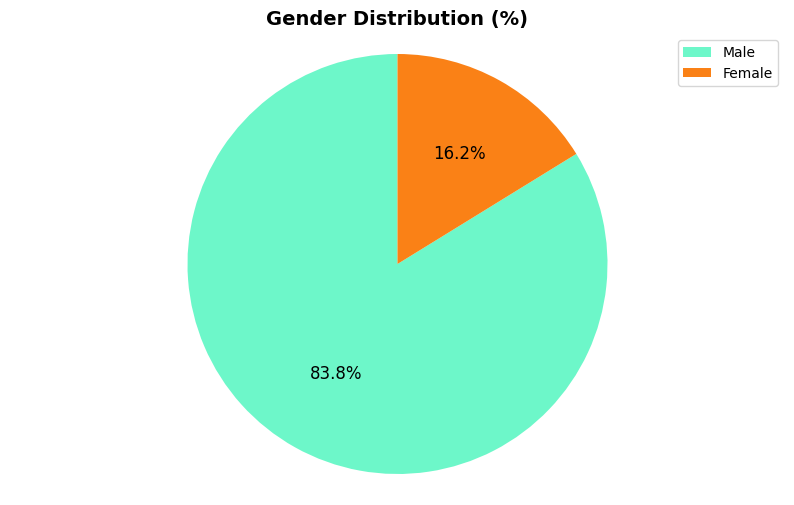

In [70]:
gender_counts = merged_df['Senior Citizen'].value_counts()
labels = gender_counts.index
sizes = gender_counts.values

# Plot pie chart
plt.figure(figsize=(10, 6))
plt.pie(sizes, autopct='%1.1f%%', startangle=90, colors=['#6df7c9','#fa8116'], textprops={'fontsize': 12})
plt.title('Gender Distribution (%)', fontsize=14, fontweight='bold')
plt.axis('equal')  # Keep circle shape
plt.legend(labels=['Male', 'Female'])
plt.show()

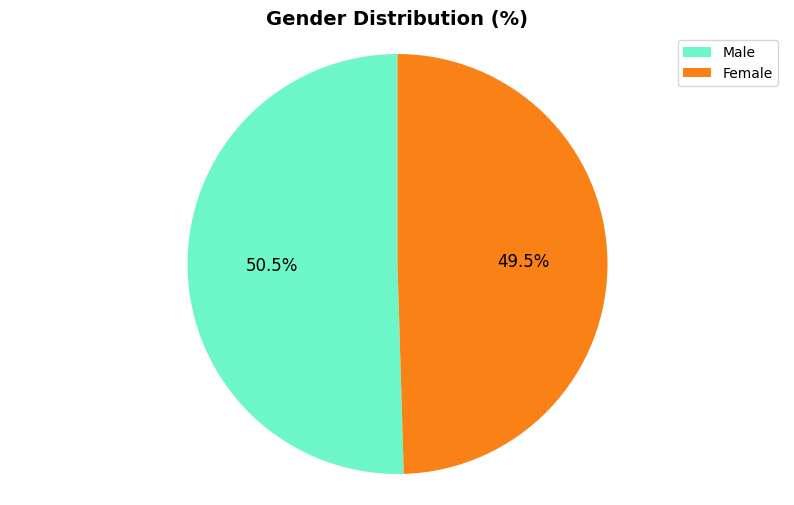

In [69]:
gender_counts = merged_df['Gender'].value_counts()
labels = gender_counts.index
sizes = gender_counts.values

# Plot pie chart
plt.figure(figsize=(10, 6))
plt.pie(sizes, autopct='%1.1f%%', startangle=90, colors=['#6df7c9','#fa8116'], textprops={'fontsize': 12})
plt.title('Gender Distribution (%)', fontsize=14, fontweight='bold')
plt.axis('equal')  # Keep circle shape
plt.legend(labels=['Male', 'Female'])
plt.show()